In [2]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
from prototype import (
    VAE, train_vae, evaluate_latentgee,
    set_seed, load_hivrc, save_dated_filename, 
)

def load_hivrc(file_path):
    data_path = Path(f"{file_path}/insight.merged_otus.txt")
    meta_path = Path(f"{file_path}/SupplementaryMaterial.xlsx")
    
    dat = pd.read_csv(data_path, sep="\t", encoding = "utf-8")
    dat_meta = pd.read_excel(meta_path, header = 1, usecols = "B:L")

    dat_cols = dat_meta["SeqID"].astype(str).to_list()
    dat_cols.insert(0, 'Resphera Insight (Raw Counts)')
    dat_T = dat[dat_cols].T
    dat_T.reset_index(inplace = True)
    dat_T.columns = dat_T.iloc[0].astype(str)
    dat_T = dat_T.iloc[1:]
    dat_T.columns.values[0] = "SeqID"
    dat_merged = pd.merge(dat_T, dat_meta, on = "SeqID", how = "inner")
        
    X = dat_T.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")
    # X_tensor = torch.tensor(X.values, dtype = torch.float32)
    
    return X, dat_merged
def compute_zero_proportion_by_prevalence(otu_df, cutoffs):
    n_samples = otu_df.shape[0]
    proportions = []

    for cutoff in cutoffs:
        # prevalence 계산: 각 OTU의 nonzero 비율
        prevalence = (otu_df > 0).sum(axis=0) / n_samples

        # cutoff 미만인 OTU 제거
        filtered_df = otu_df.loc[:, prevalence >= cutoff]

        # 전체 zero 비율 계산
        zero_count = (filtered_df == 0).sum().sum()
        total_count = filtered_df.size
        zero_proportion = zero_count / total_count

        proportions.append(zero_proportion)

    return proportions



In [3]:
file_path = "/DATA/WGS_study/YSL/projects/Data"  
data_path = Path(f"{file_path}/insight.merged_otus.txt")
meta_path = Path(f"{file_path}/SupplementaryMaterial.xlsx")

dat = pd.read_csv(data_path, sep="\t", encoding = "utf-8")
dat_meta = pd.read_excel(meta_path, header = 1, usecols = "B:L")

dat_cols = dat_meta["SeqID"].astype(str).to_list()
dat_cols.insert(0, 'Resphera Insight (Raw Counts)')
dat_T = dat[dat_cols].T
dat_T.reset_index(inplace = True)
dat_T.columns = dat_T.iloc[0].astype(str)
dat_T = dat_T.iloc[1:]
dat_T.columns.values[0] = "SeqID"
dat_merged = pd.merge(dat_T, dat_meta, on = "SeqID", how = "inner")

X = dat_merged.iloc[1:5, 1:(dat_T.shape[1])].apply(pd.to_numeric, errors="coerce")
dat_cov = dat_merged[['hivstatus', 'Age', 'gender', 'msm','ARTuse', 'cd4']]



In [4]:
print(dat_T.shape)
print(dat_merged.shape)
print(dat_meta.shape)
dat_cov = dat_merged[['hivstatus', 'Age', 'gender', 'msm','ARTuse', 'cd4']]

print(dat_cov.isna().sum())



(1032, 38126)
(1032, 38136)
(1032, 11)
hivstatus      0
Age           95
gender        41
msm          233
ARTuse       365
cd4          344
dtype: int64


In [12]:
gender_nan = dat_merged[dat_merged['gender'].isna()]
print(gender_nan['msm'].value_counts(dropna=False))

msm
NaN    40
1.0     1
Name: count, dtype: int64


In [33]:
min_sample_ratio = 0.1
presence = (X_raw > 0).sum(axis=0)
prevalence = presence / X_raw.shape[0]
otu_df = X_raw.loc[:, prevalence > min_sample_ratio]

In [ ]:
dat_merged[['Study', 'hivstatus', 'msm', 'Age', 'gender', 'cd4']]
# dat_merged.columns

,Study,hivstatus,msm,Age,gender,cd4
0,Dillon,0,NaN,27.0,1.0,NaN
1,Dillon,1,1.0,48.0,1.0,400.0
2,Dillon,1,1.0,25.0,1.0,532.0
3,Dillon,0,NaN,29.0,1.0,NaN
4,Dillon,1,0.0,58.0,0.0,400.0
...,...,...,...,...,...,...
1027,Yu,0,1.0,42.0,1.0,NaN
1028,Yu,0,1.0,37.0,1.0,NaN
1029,Yu,0,1.0,54.0,1.0,NaN
1030,Yu,0,1.0,41.0,1.0,NaN


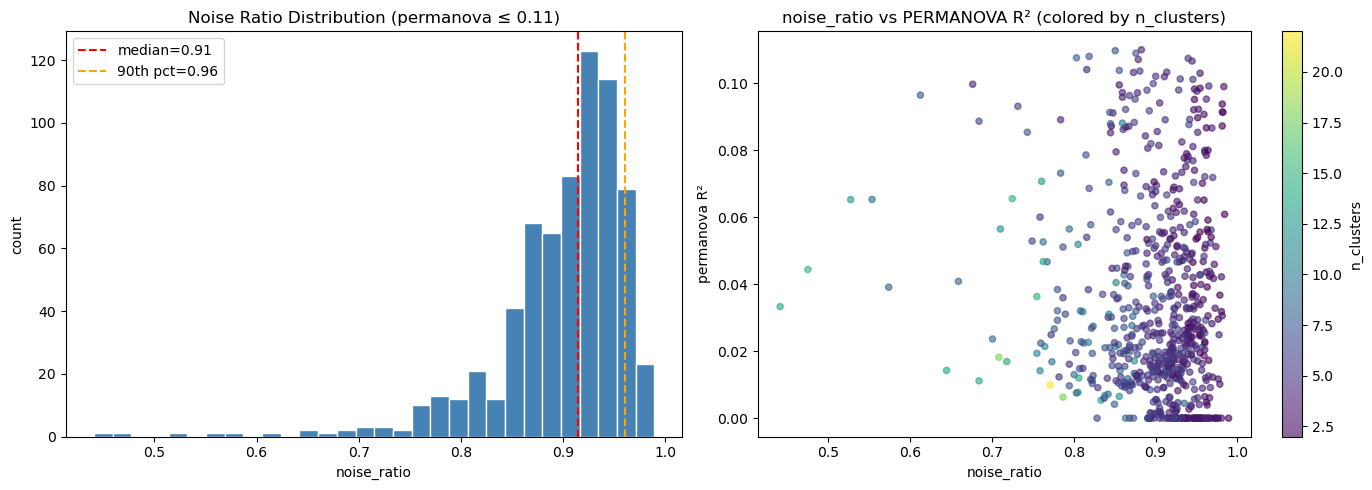

count    683.000000
mean       0.898619
std        0.065893
min        0.440891
25%        0.871609
50%        0.914729
75%        0.941376
max        0.989341
Name: noise_ratio, dtype: float64

trial 수: 683


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


file_path = "/DATA/WGS_study/YSL/projects/latentgee/examples/logs"  
df = pd.read_csv(f"{file_path}/optuna_trials_2026-03-26.csv")

# permanova 0~0.11 필터
df_valid = df[df['permanova'] <= 0.11].sort_values('permanova').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 플랏 1: noise_ratio 히스토그램
axes[0].hist(df_valid['noise_ratio'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df_valid['noise_ratio'].median(), color='red', linestyle='--', label=f"median={df_valid['noise_ratio'].median():.2f}")
axes[0].axvline(df_valid['noise_ratio'].quantile(0.9), color='orange', linestyle='--', label=f"90th pct={df_valid['noise_ratio'].quantile(0.9):.2f}")
axes[0].set_xlabel('noise_ratio')
axes[0].set_ylabel('count')
axes[0].set_title('Noise Ratio Distribution (permanova ≤ 0.11)')
axes[0].legend()

# ── 플랏 2: noise_ratio vs permanova scatter
sc = axes[1].scatter(df_valid['noise_ratio'], df_valid['permanova'],
                     c=df_valid['n_clusters'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[1], label='n_clusters')
axes[1].set_xlabel('noise_ratio')
axes[1].set_ylabel('permanova R²')
axes[1].set_title('noise_ratio vs PERMANOVA R² (colored by n_clusters)')

plt.tight_layout()
plt.savefig("noise_ratio_analysis.png", dpi=150)
plt.show()

# 요약 통계
print(df_valid['noise_ratio'].describe())
print(f"\ntrial 수: {len(df_valid)}")